In [1]:
# Libraries and configurations
import sys
from pathlib import Path
import json

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision import transforms
from torchinfo import summary

# Visualization and analysis
import os
import seaborn as sns
import PIL
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score

# Adds the project root to the path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from config import (
    get_dataset_paths
)

from src.dataset import DataModuleParasite
from src import utils
from src import models
from src import trainer

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

### Eggs: Trained from Scratch

In [11]:
# Configuration for Eggs Dataset

CONFIG_EGG = {
    'dataset_name': 'eggs',
    'split': [1, 2, 3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 9,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_EGG['dataset_name']
model_name = 'resnet18_scratch'
type_model = 'resnet18'
pre_trained = False
path = f"{type_model}/{model_name}/{dataset_name}"
config = CONFIG_EGG
dataloaders = {}

transforms_egg = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = utils.create_dataloaders(config=config, transforms=transforms_egg)

model_scratch, _, _, _ = models.create_model(type_model=type_model, description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config, pre_trained=pre_trained)

n_flops, n_params = utils.count_flops(model_scratch, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: resnet18_scratch - Dataset: eggs
FLOPs: 1563977728.0 FLOPs
Parameters: 11181129.0 


In [12]:
# Training loop with pre-trained weights
historic_train = trainer.train_loop(config, dataloaders, path, dataset_name, model_name=model_name, type_model=type_model, pre_trained=pre_trained)

# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)
    

Early stopping at epoch 21 for split 1 and percentage 1%


Early stopping at epoch 26 for split 2 and percentage 1%


Early stopping at epoch 28 for split 3 and percentage 1%


Early stopping at epoch 51 for split 1 and percentage 5%


Early stopping at epoch 37 for split 2 and percentage 5%


...

Early stopping at epoch 59 for split 2 and percentage 75%


Early stopping at epoch 60 for split 3 and percentage 75%


Early stopping at epoch 36 for split 1 and percentage 100%


Early stopping at epoch 49 for split 2 and percentage 100%


Early stopping at epoch 38 for split 3 and percentage 100%


In [13]:
utils.loss_and_accuracy_split(config, path, model_name, show_plot=False)
utils.loss_and_accuracy_aggregate(config, path, model_name, show_plot=False)

results_test = utils.evaluate_test_set(config, path, model_name, dataloaders, type_model=type_model, pre_trained=pre_trained)  

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)

utils.calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to resnet18/resnet18_scratch/eggs/resnet18_scratch_aggregated_classification_report_eggs.txt


### Larvae: Trained from Scratch

In [14]:
# Configuration for Larvae Dataset
CONFIG_LARVAE = {
    'dataset_name': 'larvae',
    'split': [1,2,3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 2,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_LARVAE['dataset_name']
model_name = 'resnet18_scratch'
type_model = 'resnet18'
pre_trained = False
path = f"{type_model}/{model_name}/{dataset_name}"
config = CONFIG_LARVAE
dataloaders = {}

transforms_larvae = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = utils.create_dataloaders(config=config, transforms=transforms_larvae)

model_scratch, _, _, _ = models.create_model(type_model=type_model, description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config, pre_trained=pre_trained)

n_flops, n_params = utils.count_flops(model_scratch, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: resnet18_scratch - Dataset: larvae
FLOPs: 1563974144.0 FLOPs
Parameters: 11177538.0 


In [15]:
# Training loop with pre-trained weights
historic_train = trainer.train_loop(config, dataloaders, path, dataset_name, model_name=model_name, type_model=type_model, pre_trained=pre_trained)

# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)

Early stopping at epoch 31 for split 1 and percentage 1%


Early stopping at epoch 22 for split 2 and percentage 1%


Early stopping at epoch 21 for split 3 and percentage 1%


Early stopping at epoch 35 for split 1 and percentage 5%


Early stopping at epoch 47 for split 2 and percentage 5%


...

Early stopping at epoch 47 for split 2 and percentage 75%


Early stopping at epoch 28 for split 3 and percentage 75%


Early stopping at epoch 30 for split 1 and percentage 100%


Early stopping at epoch 30 for split 2 and percentage 100%


Early stopping at epoch 32 for split 3 and percentage 100%


In [16]:
utils.loss_and_accuracy_split(config, path, model_name, show_plot=False)
utils.loss_and_accuracy_aggregate(config, path, model_name, show_plot=False)

results_test = utils.evaluate_test_set(config, path, model_name, dataloaders, type_model=type_model, pre_trained=pre_trained)  

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)

utils.calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to resnet18/resnet18_scratch/larvae/resnet18_scratch_aggregated_classification_report_larvae.txt


### Cysts: Trained from Scratch

In [2]:
# Configuration for Cisto Dataset
CONFIG_CISTO = {
    'dataset_name': 'cistos',
    'split': [1, 2, 3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 7,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_CISTO['dataset_name']
model_name = 'resnet18_scratch'
type_model = 'resnet18'
pre_trained = False
path = f"{type_model}/{model_name}/{dataset_name}"
config = CONFIG_CISTO
dataloaders = {}

transforms_cistos = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = utils.create_dataloaders(config=config, transforms=transforms_cistos)

model_scratch, _, _, _ = models.create_model(type_model=type_model, description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config, pre_trained=pre_trained)

n_flops, n_params = utils.count_flops(model_scratch, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: resnet18_scratch - Dataset: cistos
FLOPs: 1563976704.0 FLOPs
Parameters: 11180103.0 


In [18]:
# Training loop with pre-trained weights
historic_train = trainer.train_loop(config, dataloaders, path, dataset_name, model_name=model_name, type_model=type_model, pre_trained=pre_trained)

# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)

Early stopping at epoch 27 for split 1 and percentage 1%


Early stopping at epoch 48 for split 2 and percentage 1%


Early stopping at epoch 22 for split 3 and percentage 1%


Early stopping at epoch 48 for split 1 and percentage 5%


Early stopping at epoch 46 for split 2 and percentage 5%


...

Early stopping at epoch 61 for split 2 and percentage 75%


Early stopping at epoch 77 for split 3 and percentage 75%


Early stopping at epoch 46 for split 1 and percentage 100%


Early stopping at epoch 48 for split 2 and percentage 100%


Early stopping at epoch 58 for split 3 and percentage 100%


In [3]:
utils.loss_and_accuracy_split(config, path, model_name, show_plot=False)
utils.loss_and_accuracy_aggregate(config, path, model_name, show_plot=False)

results_test = utils.evaluate_test_set(config, path, model_name, dataloaders, type_model=type_model, pre_trained=pre_trained)  

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)

utils.calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to resnet18/resnet18_scratch/cistos/resnet18_scratch_aggregated_classification_report_cistos.txt


### Eggs: Pre-trained on ImageNet

In [2]:
# Configuration for Eggs Dataset

CONFIG_EGG = {
    'dataset_name': 'eggs',
    'split': [1, 2, 3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 9,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_EGG['dataset_name']
model_name = 'resnet18_pretrained'
type_model = 'resnet18'
pre_trained = True
path = f"{type_model}/{model_name}/{dataset_name}"
config = CONFIG_EGG
dataloaders = {}

transforms_egg = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = utils.create_dataloaders(config=config, transforms=transforms_egg)

model_scratch, _, _, _ = models.create_model(type_model=type_model, description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config, pre_trained=pre_trained)

n_flops, n_params = utils.count_flops(model_scratch, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: resnet18_pretrained - Dataset: eggs
FLOPs: 1563977728.0 FLOPs
Parameters: 11181129.0 


In [21]:
# Training loop with pre-trained weights
historic_train = trainer.train_loop(config, dataloaders, path, dataset_name, model_name=model_name, type_model=type_model, pre_trained=pre_trained)

# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)
    

Early stopping at epoch 90 for split 1 and percentage 1%


Early stopping at epoch 65 for split 2 and percentage 1%


Early stopping at epoch 64 for split 3 and percentage 1%


Early stopping at epoch 33 for split 1 and percentage 5%


Early stopping at epoch 41 for split 2 and percentage 5%


...

Early stopping at epoch 48 for split 2 and percentage 75%


Early stopping at epoch 45 for split 3 and percentage 75%


Early stopping at epoch 35 for split 1 and percentage 100%


Early stopping at epoch 31 for split 2 and percentage 100%


Early stopping at epoch 30 for split 3 and percentage 100%


In [22]:
utils.loss_and_accuracy_split(config, path, model_name, show_plot=False)
utils.loss_and_accuracy_aggregate(config, path, model_name, show_plot=False)

results_test = utils.evaluate_test_set(config, path, model_name, dataloaders, type_model=type_model, pre_trained=pre_trained)  

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)

utils.calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to resnet18/resnet18_pretrained/eggs/resnet18_pretrained_aggregated_classification_report_eggs.txt


Input shape: torch.Size([1, 3, 200, 200])
Feature map shape (última conv): torch.Size([1, 512, 7, 7])
Logits shape: torch.Size([1, 9])


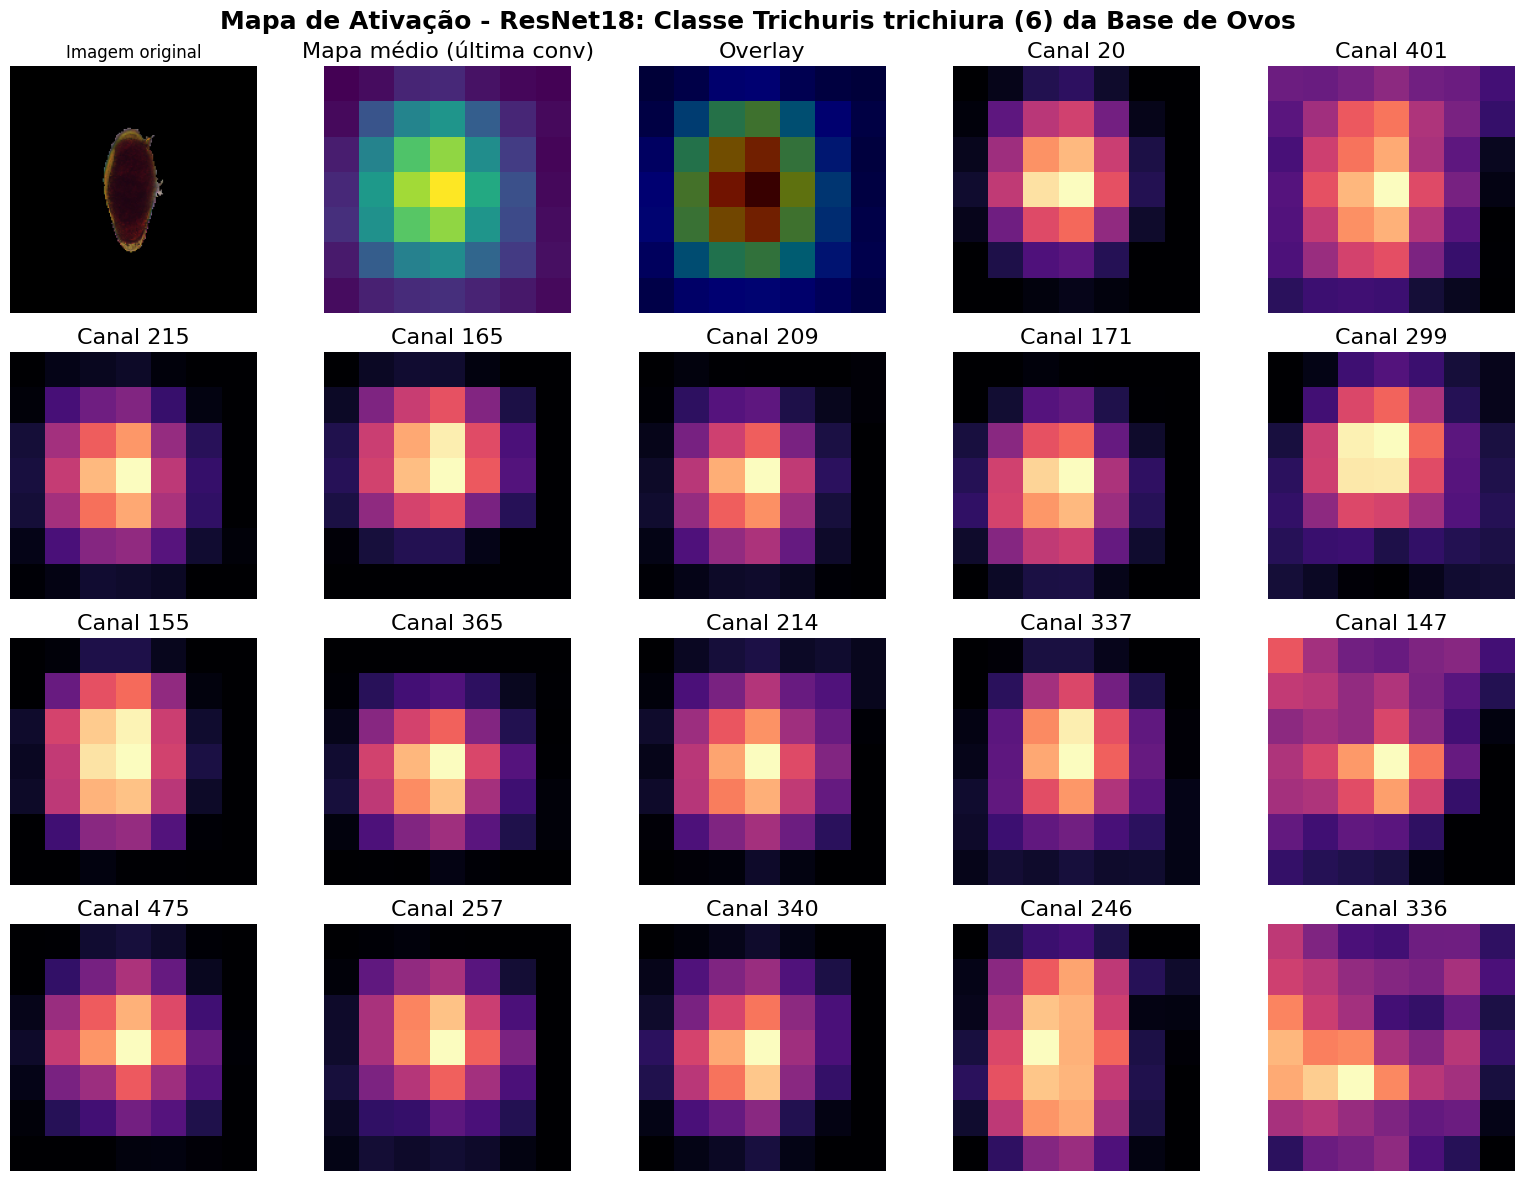

In [27]:
# Visualizar mapa de ativação após a última camada convolucional (antes da FC)

def _find_first_dataloader(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            dl = _find_first_dataloader(v)
            if dl is not None:
                return dl
    elif hasattr(obj, "dataset") and hasattr(obj, "__iter__"):
        return obj
    return None

loader = _find_first_dataloader(dataloaders)
if loader is None:
    raise ValueError("Nenhum DataLoader encontrado em 'dataloaders'.")

# quero escolher a classe da imagem
chosen_class = 6  # Altere para a classe desejada (0 a num_classes-1)

num_classes = config["num_classes"]
if not (0 <= chosen_class < num_classes):
    raise ValueError(f"chosen_class={chosen_class} inválida. Use valores entre 0 e {num_classes - 1}.")

# pegar a primeira imagem da classe escolhida (procurando em todos os batches)
images = None
for batch_images, batch_labels in loader:
    mask = (batch_labels == chosen_class)
    if mask.any().item():
        images = batch_images[mask][:1]  # 1 imagem
        break

if images is None:
    raise ValueError(f"Nenhuma imagem da classe {chosen_class} encontrada neste DataLoader.")

x = images.to(config["device"])  # 1 imagem

model_scratch = model_scratch.to(config["device"]).eval()

with torch.no_grad():
    h = model_scratch.conv1(x)
    h = model_scratch.bn1(h)
    h = model_scratch.relu(h)
    h = model_scratch.maxpool(h)

    h = model_scratch.layer1(h)
    h = model_scratch.layer2(h)
    h = model_scratch.layer3(h)
    feat = model_scratch.layer4(h)  # saída da última parte convolucional

    pooled = model_scratch.avgpool(feat)
    logits = model_scratch.fc(torch.flatten(pooled, 1))

print(f"Input shape: {x.shape}")
print(f"Feature map shape (última conv): {feat.shape}")
print(f"Logits shape: {logits.shape}")

# --- Preparar imagem original (desnormalizar para plot) ---
img_np = images[0].permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

feat_cpu = feat[0].detach().cpu()  # [C, H, W]

# Mapa agregado (média nos canais)
mean_map = feat_cpu.mean(dim=0).numpy()
mean_map = (mean_map - mean_map.min()) / (mean_map.max() - mean_map.min() + 1e-8)

# Top-17 canais mais "ativos"
channel_score = feat_cpu.view(feat_cpu.size(0), -1).mean(dim=1)
k = min(17, feat_cpu.size(0))
top_idx = torch.topk(channel_score, k=k).indices

# --- Plot ---
fig = plt.figure(figsize=(16, 12))
plt.suptitle(f"Mapa de Ativação - ResNet18: Classe Trichuris trichiura ({chosen_class}) da Base de Ovos ", fontsize=18, fontweight='bold')

ax1 = plt.subplot(4, 5, 1)
ax1.imshow(img_np)
ax1.set_title("Imagem original")
ax1.axis("off")

ax2 = plt.subplot(4, 5, 2)
ax2.imshow(mean_map, cmap="viridis")
ax2.set_title("Mapa médio (última conv)", fontsize=16)
ax2.axis("off")

ax3 = plt.subplot(4, 5, 3)
ax3.imshow(img_np)
ax3.imshow(mean_map, cmap="jet", alpha=0.45)
ax3.set_title("Overlay", fontsize=16)
ax3.axis("off")

for i, ch in enumerate(top_idx, start=4):
    ax = plt.subplot(4, 5, i)
    fmap = feat_cpu[ch].numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    ax.imshow(fmap, cmap="magma")
    ax.set_title(f"Canal {int(ch)}", fontsize=16)
    ax.axis("off")

plt.tight_layout()
plt.show()

Input shape: torch.Size([1, 3, 200, 200])
Feature map shape (última conv): torch.Size([1, 512, 7, 7])
Logits shape: torch.Size([1, 9])


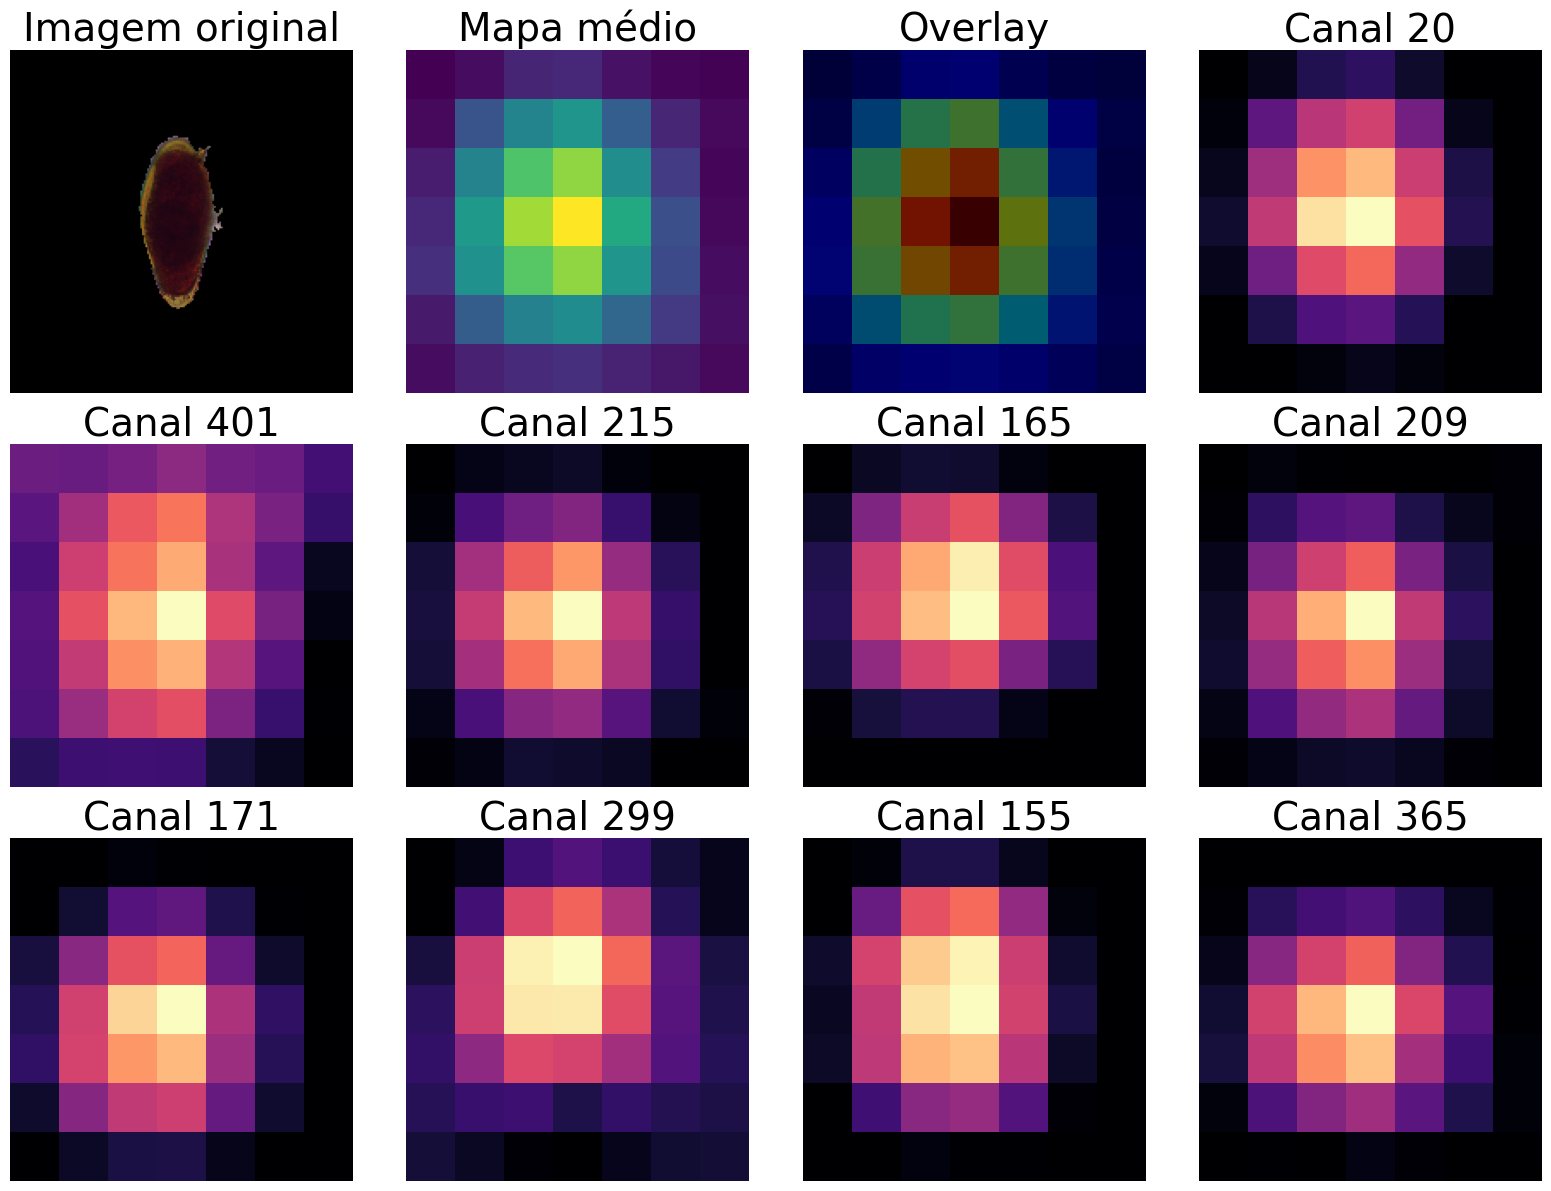

In [19]:
# Visualizar mapa de ativação após a última camada convolucional (antes da FC)

def _find_first_dataloader(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            dl = _find_first_dataloader(v)
            if dl is not None:
                return dl
    elif hasattr(obj, "dataset") and hasattr(obj, "__iter__"):
        return obj
    return None

loader = _find_first_dataloader(dataloaders)
if loader is None:
    raise ValueError("Nenhum DataLoader encontrado em 'dataloaders'.")

# quero escolher a classe da imagem
chosen_class = 6  # Altere para a classe desejada (0 a num_classes-1)

num_classes = config["num_classes"]
if not (0 <= chosen_class < num_classes):
    raise ValueError(f"chosen_class={chosen_class} inválida. Use valores entre 0 e {num_classes - 1}.")

# pegar a primeira imagem da classe escolhida (procurando em todos os batches)
images = None
for batch_images, batch_labels in loader:
    mask = (batch_labels == chosen_class)
    if mask.any().item():
        images = batch_images[mask][:1]  # 1 imagem
        break

if images is None:
    raise ValueError(f"Nenhuma imagem da classe {chosen_class} encontrada neste DataLoader.")

x = images.to(config["device"])  # 1 imagem

model_scratch = model_scratch.to(config["device"]).eval()

with torch.no_grad():
    h = model_scratch.conv1(x)
    h = model_scratch.bn1(h)
    h = model_scratch.relu(h)
    h = model_scratch.maxpool(h)

    h = model_scratch.layer1(h)
    h = model_scratch.layer2(h)
    h = model_scratch.layer3(h)
    feat = model_scratch.layer4(h)  # saída da última parte convolucional

    pooled = model_scratch.avgpool(feat)
    logits = model_scratch.fc(torch.flatten(pooled, 1))

print(f"Input shape: {x.shape}")
print(f"Feature map shape (última conv): {feat.shape}")
print(f"Logits shape: {logits.shape}")

# --- Preparar imagem original (desnormalizar para plot) ---
img_np = images[0].permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

feat_cpu = feat[0].detach().cpu()  # [C, H, W]

# Mapa agregado (média nos canais)
mean_map = feat_cpu.mean(dim=0).numpy()
mean_map = (mean_map - mean_map.min()) / (mean_map.max() - mean_map.min() + 1e-8)
# Top-9 canais mais "ativos"
channel_score = feat_cpu.view(feat_cpu.size(0), -1).mean(dim=1)
k = min(9, feat_cpu.size(0))
top_idx = torch.topk(channel_score, k=k).indices

# --- Plot em grade 4x3 (12 posições): original, média, overlay + 9 canais ---
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

# plt.suptitle(
#     f"Mapa de Ativação - ResNet18 | Classe {chosen_class}",
#     fontsize=18,
#     fontweight="bold"
# )

qtd  = 28

# 1) imagem original
axes[0].imshow(img_np)
axes[0].set_title("Imagem original", fontsize=qtd)
axes[0].axis("off")

# 2) mapa médio
axes[1].imshow(mean_map, cmap="viridis")
# axes[1].set_title("Mapa médio (última conv)", fontsize=qtd)
axes[1].set_title("Mapa médio", fontsize=qtd)
axes[1].axis("off")

# 3) overlay
axes[2].imshow(img_np)
axes[2].imshow(mean_map, cmap="jet", alpha=0.45)
axes[2].set_title("Overlay", fontsize=qtd)
axes[2].axis("off")

# 4..12) top-9 canais
for i, ch in enumerate(top_idx, start=3):
    fmap = feat_cpu[ch].numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    axes[i].imshow(fmap, cmap="magma")
    axes[i].set_title(f"Canal {int(ch)}", fontsize=qtd)
    axes[i].axis("off")

# caso k < 9, desliga eixos restantes
for j in range(3 + k, 12):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


Input shape: torch.Size([1, 3, 200, 200])
Feature map shape (última conv): torch.Size([1, 512, 7, 7])
Logits shape: torch.Size([1, 9])


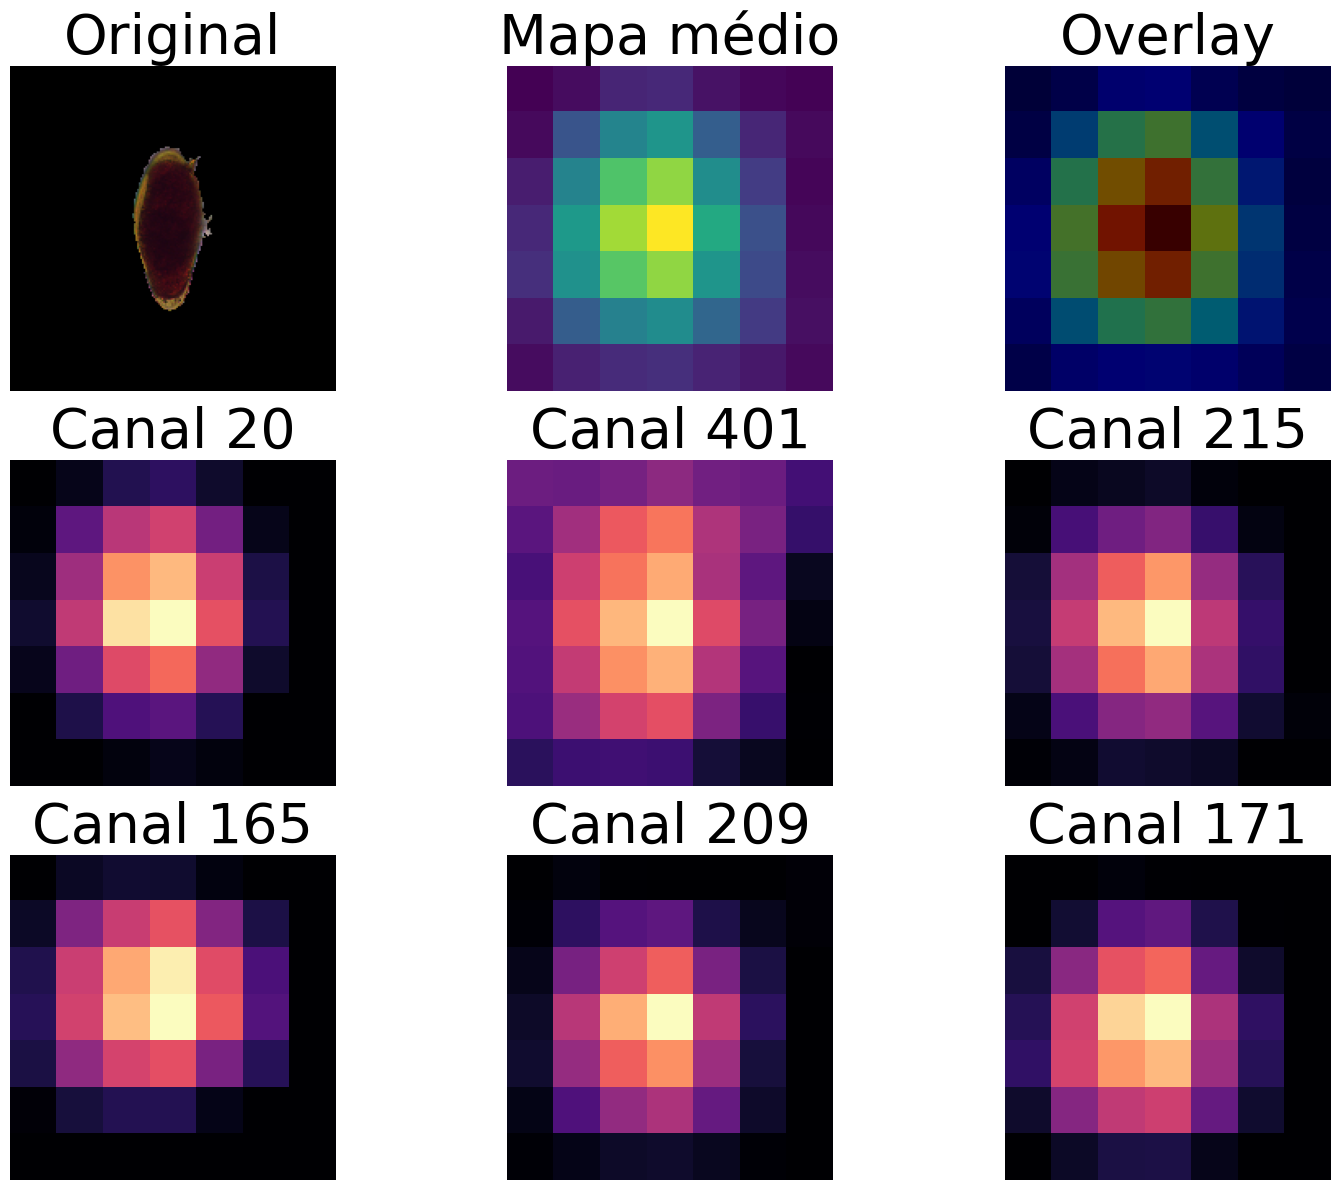

In [25]:
# Visualizar mapa de ativação após a última camada convolucional (antes da FC)

def _find_first_dataloader(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            dl = _find_first_dataloader(v)
            if dl is not None:
                return dl
    elif hasattr(obj, "dataset") and hasattr(obj, "__iter__"):
        return obj
    return None

loader = _find_first_dataloader(dataloaders)
if loader is None:
    raise ValueError("Nenhum DataLoader encontrado em 'dataloaders'.")

# quero escolher a classe da imagem
chosen_class = 6  # Altere para a classe desejada (0 a num_classes-1)

num_classes = config["num_classes"]
if not (0 <= chosen_class < num_classes):
    raise ValueError(f"chosen_class={chosen_class} inválida. Use valores entre 0 e {num_classes - 1}.")

# pegar a primeira imagem da classe escolhida (procurando em todos os batches)
images = None
for batch_images, batch_labels in loader:
    mask = (batch_labels == chosen_class)
    if mask.any().item():
        images = batch_images[mask][:1]  # 1 imagem
        break

if images is None:
    raise ValueError(f"Nenhuma imagem da classe {chosen_class} encontrada neste DataLoader.")

x = images.to(config["device"])  # 1 imagem

model_scratch = model_scratch.to(config["device"]).eval()

with torch.no_grad():
    h = model_scratch.conv1(x)
    h = model_scratch.bn1(h)
    h = model_scratch.relu(h)
    h = model_scratch.maxpool(h)

    h = model_scratch.layer1(h)
    h = model_scratch.layer2(h)
    h = model_scratch.layer3(h)
    feat = model_scratch.layer4(h)  # saída da última parte convolucional

    pooled = model_scratch.avgpool(feat)
    logits = model_scratch.fc(torch.flatten(pooled, 1))

print(f"Input shape: {x.shape}")
print(f"Feature map shape (última conv): {feat.shape}")
print(f"Logits shape: {logits.shape}")

# --- Preparar imagem original (desnormalizar para plot) ---
img_np = images[0].permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

feat_cpu = feat[0].detach().cpu()  # [C, H, W]

# Mapa agregado (média nos canais)
mean_map = feat_cpu.mean(dim=0).numpy()
mean_map = (mean_map - mean_map.min()) / (mean_map.max() - mean_map.min() + 1e-8)

# Top-6 canais mais "ativos"
channel_score = feat_cpu.view(feat_cpu.size(0), -1).mean(dim=1)
k = min(6, feat_cpu.size(0))
top_idx = torch.topk(channel_score, k=k).indices

# --- Plot em grade 3x3 (9 posições): original, média, overlay + 6 canais ---
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

# plt.suptitle(
#     f"Mapa de Ativação - ResNet18 | Classe {chosen_class}",
#     fontsize=18,
#     fontweight="bold"
# )

qtd  = 40

# 1) imagem original
axes[0].imshow(img_np)
axes[0].set_title("Original", fontsize=qtd)
axes[0].axis("off")

# 2) mapa médio
axes[1].imshow(mean_map, cmap="viridis")
# axes[1].set_title("Mapa médio (última conv)", fontsize=qtd)
axes[1].set_title("Mapa médio", fontsize=qtd)
axes[1].axis("off")

# 3) overlay
axes[2].imshow(img_np)
axes[2].imshow(mean_map, cmap="jet", alpha=0.45)
axes[2].set_title("Overlay", fontsize=qtd)
axes[2].axis("off")

# 4..12) top-9 canais
for i, ch in enumerate(top_idx, start=3):
    fmap = feat_cpu[ch].numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    axes[i].imshow(fmap, cmap="magma")
    axes[i].set_title(f"Canal {int(ch)}", fontsize=qtd)
    axes[i].axis("off")

# caso k < 9, desliga eixos restantes
for j in range(3 + k, 9):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


### Larvae: Pre-trained on ImageNet

In [26]:
# Configuration for Larvae Dataset
CONFIG_LARVAE = {
    'dataset_name': 'larvae',
    'split': [1,2,3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 2,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_LARVAE['dataset_name']
model_name = 'resnet18_pretrained'
type_model = 'resnet18'
pre_trained = True
path = f"{type_model}/{model_name}/{dataset_name}"
config = CONFIG_LARVAE
dataloaders = {}

transforms_larvae = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = utils.create_dataloaders(config=config, transforms=transforms_larvae)

model_scratch, _, _, _ = models.create_model(type_model=type_model, description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config, pre_trained=pre_trained)

n_flops, n_params = utils.count_flops(model_scratch, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: resnet18_pretrained - Dataset: larvae
FLOPs: 1563974144.0 FLOPs
Parameters: 11177538.0 


Input shape: torch.Size([1, 3, 200, 200])
Feature map shape (última conv): torch.Size([1, 512, 7, 7])
Logits shape: torch.Size([1, 2])


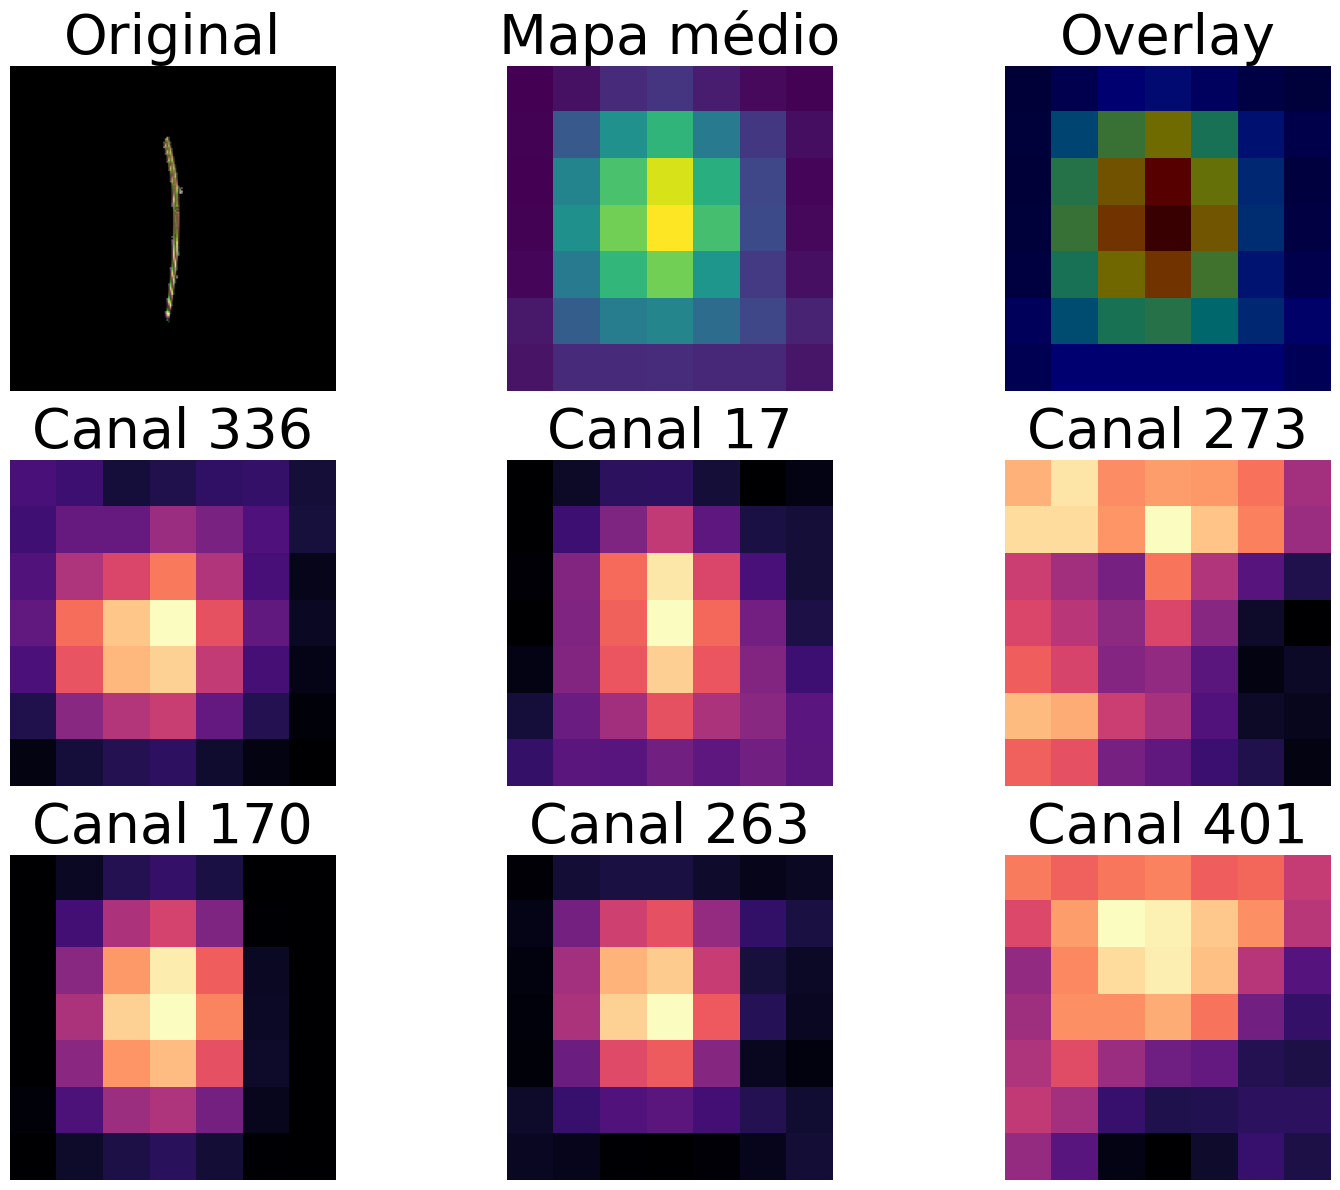

In [27]:
# Visualizar mapa de ativação após a última camada convolucional (antes da FC)

def _find_first_dataloader(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            dl = _find_first_dataloader(v)
            if dl is not None:
                return dl
    elif hasattr(obj, "dataset") and hasattr(obj, "__iter__"):
        return obj
    return None

loader = _find_first_dataloader(dataloaders)
if loader is None:
    raise ValueError("Nenhum DataLoader encontrado em 'dataloaders'.")

# quero escolher a classe da imagem
chosen_class = 1  # Altere para a classe desejada (0 a num_classes-1)

num_classes = config["num_classes"]
if not (0 <= chosen_class < num_classes):
    raise ValueError(f"chosen_class={chosen_class} inválida. Use valores entre 0 e {num_classes - 1}.")

# pegar a primeira imagem da classe escolhida (procurando em todos os batches)
images = None
for batch_images, batch_labels in loader:
    mask = (batch_labels == chosen_class)
    if mask.any().item():
        images = batch_images[mask][:1]  # 1 imagem
        break

if images is None:
    raise ValueError(f"Nenhuma imagem da classe {chosen_class} encontrada neste DataLoader.")

x = images.to(config["device"])  # 1 imagem

model_scratch = model_scratch.to(config["device"]).eval()

with torch.no_grad():
    h = model_scratch.conv1(x)
    h = model_scratch.bn1(h)
    h = model_scratch.relu(h)
    h = model_scratch.maxpool(h)

    h = model_scratch.layer1(h)
    h = model_scratch.layer2(h)
    h = model_scratch.layer3(h)
    feat = model_scratch.layer4(h)  # saída da última parte convolucional

    pooled = model_scratch.avgpool(feat)
    logits = model_scratch.fc(torch.flatten(pooled, 1))

print(f"Input shape: {x.shape}")
print(f"Feature map shape (última conv): {feat.shape}")
print(f"Logits shape: {logits.shape}")

# --- Preparar imagem original (desnormalizar para plot) ---
img_np = images[0].permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

feat_cpu = feat[0].detach().cpu()  # [C, H, W]

# Mapa agregado (média nos canais)
mean_map = feat_cpu.mean(dim=0).numpy()
mean_map = (mean_map - mean_map.min()) / (mean_map.max() - mean_map.min() + 1e-8)

# Top-6 canais mais "ativos"
channel_score = feat_cpu.view(feat_cpu.size(0), -1).mean(dim=1)
k = min(6, feat_cpu.size(0))
top_idx = torch.topk(channel_score, k=k).indices

# --- Plot em grade 3x3 (9 posições): original, média, overlay + 6 canais ---
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

# plt.suptitle(
#     f"Mapa de Ativação - ResNet18 | Classe {chosen_class}",
#     fontsize=18,
#     fontweight="bold"
# )

qtd  = 40

# 1) imagem original
axes[0].imshow(img_np)
axes[0].set_title("Original", fontsize=qtd)
axes[0].axis("off")

# 2) mapa médio
axes[1].imshow(mean_map, cmap="viridis")
# axes[1].set_title("Mapa médio (última conv)", fontsize=qtd)
axes[1].set_title("Mapa médio", fontsize=qtd)
axes[1].axis("off")

# 3) overlay
axes[2].imshow(img_np)
axes[2].imshow(mean_map, cmap="jet", alpha=0.45)
axes[2].set_title("Overlay", fontsize=qtd)
axes[2].axis("off")

# 4..12) top-9 canais
for i, ch in enumerate(top_idx, start=3):
    fmap = feat_cpu[ch].numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    axes[i].imshow(fmap, cmap="magma")
    axes[i].set_title(f"Canal {int(ch)}", fontsize=qtd)
    axes[i].axis("off")

# caso k < 9, desliga eixos restantes
for j in range(3 + k, 9):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


Input shape: torch.Size([1, 3, 200, 200])
Feature map shape (última conv): torch.Size([1, 512, 7, 7])
Logits shape: torch.Size([1, 2])


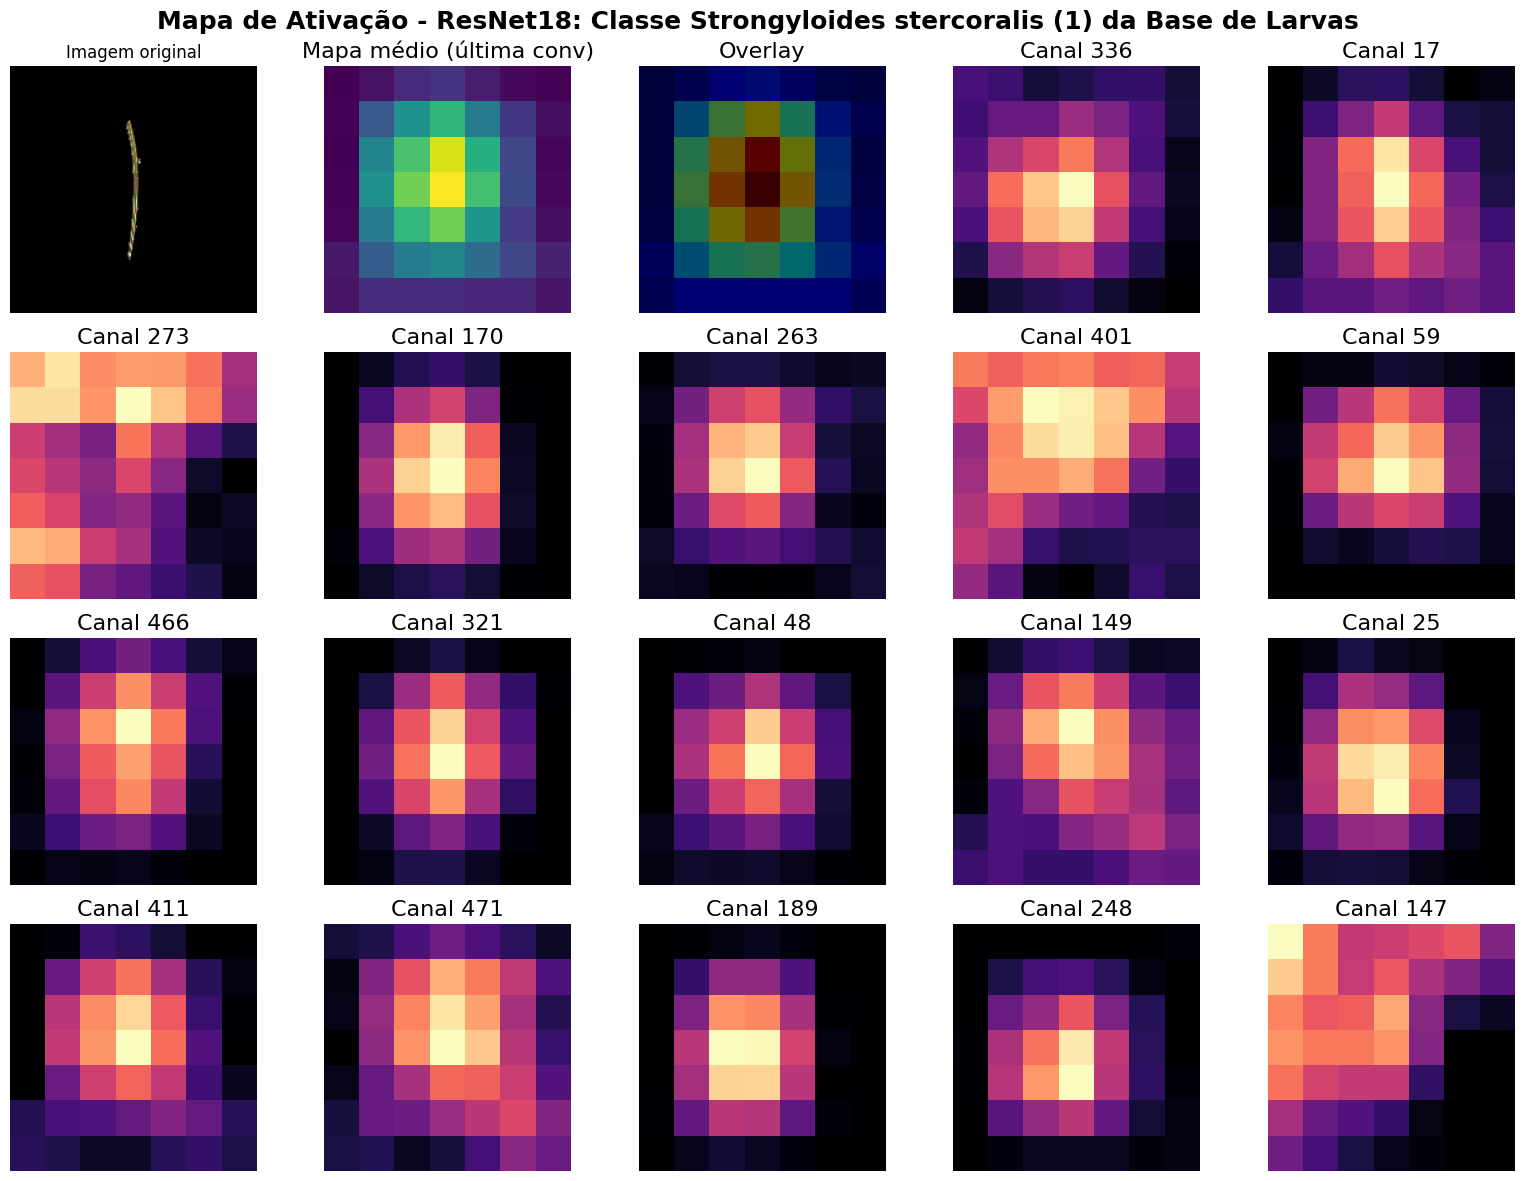

In [29]:
# Visualizar mapa de ativação após a última camada convolucional (antes da FC)

def _find_first_dataloader(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            dl = _find_first_dataloader(v)
            if dl is not None:
                return dl
    elif hasattr(obj, "dataset") and hasattr(obj, "__iter__"):
        return obj
    return None

loader = _find_first_dataloader(dataloaders)
if loader is None:
    raise ValueError("Nenhum DataLoader encontrado em 'dataloaders'.")

# quero escolher a classe da imagem
chosen_class = 1  # Altere para a classe desejada (0 a num_classes-1)

num_classes = config["num_classes"]
if not (0 <= chosen_class < num_classes):
    raise ValueError(f"chosen_class={chosen_class} inválida. Use valores entre 0 e {num_classes - 1}.")

# pegar a primeira imagem da classe escolhida (procurando em todos os batches)
images = None
for batch_images, batch_labels in loader:
    mask = (batch_labels == chosen_class)
    if mask.any().item():
        images = batch_images[mask][:1]  # 1 imagem
        break

if images is None:
    raise ValueError(f"Nenhuma imagem da classe {chosen_class} encontrada neste DataLoader.")

x = images.to(config["device"])  # 1 imagem

model_scratch = model_scratch.to(config["device"]).eval()

with torch.no_grad():
    h = model_scratch.conv1(x)
    h = model_scratch.bn1(h)
    h = model_scratch.relu(h)
    h = model_scratch.maxpool(h)

    h = model_scratch.layer1(h)
    h = model_scratch.layer2(h)
    h = model_scratch.layer3(h)
    feat = model_scratch.layer4(h)  # saída da última parte convolucional

    pooled = model_scratch.avgpool(feat)
    logits = model_scratch.fc(torch.flatten(pooled, 1))

print(f"Input shape: {x.shape}")
print(f"Feature map shape (última conv): {feat.shape}")
print(f"Logits shape: {logits.shape}")

# --- Preparar imagem original (desnormalizar para plot) ---
img_np = images[0].permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

feat_cpu = feat[0].detach().cpu()  # [C, H, W]

# Mapa agregado (média nos canais)
mean_map = feat_cpu.mean(dim=0).numpy()
mean_map = (mean_map - mean_map.min()) / (mean_map.max() - mean_map.min() + 1e-8)

# Top-17 canais mais "ativos"
channel_score = feat_cpu.view(feat_cpu.size(0), -1).mean(dim=1)
k = min(17, feat_cpu.size(0))
top_idx = torch.topk(channel_score, k=k).indices

# --- Plot ---
fig = plt.figure(figsize=(16, 12))
plt.suptitle(f"Mapa de Ativação - ResNet18: Classe Strongyloides stercoralis ({chosen_class}) da Base de Larvas ", fontsize=18, fontweight='bold')

ax1 = plt.subplot(4, 5, 1)
ax1.imshow(img_np)
ax1.set_title("Imagem original")
ax1.axis("off")

ax2 = plt.subplot(4, 5, 2)
ax2.imshow(mean_map, cmap="viridis")
ax2.set_title("Mapa médio (última conv)", fontsize=16)
ax2.axis("off")

ax3 = plt.subplot(4, 5, 3)
ax3.imshow(img_np)
ax3.imshow(mean_map, cmap="jet", alpha=0.45)
ax3.set_title("Overlay", fontsize=16)
ax3.axis("off")

for i, ch in enumerate(top_idx, start=4):
    ax = plt.subplot(4, 5, i)
    fmap = feat_cpu[ch].numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    ax.imshow(fmap, cmap="magma")
    ax.set_title(f"Canal {int(ch)}", fontsize=16)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [24]:
# Training loop with pre-trained weights
historic_train = trainer.train_loop(config, dataloaders, path, dataset_name, model_name=model_name, type_model=type_model, pre_trained=pre_trained)

# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)
    

Early stopping at epoch 21 for split 1 and percentage 1%


Early stopping at epoch 21 for split 2 and percentage 1%


Early stopping at epoch 32 for split 3 and percentage 1%


Early stopping at epoch 32 for split 1 and percentage 5%


Early stopping at epoch 25 for split 2 and percentage 5%


...

Early stopping at epoch 27 for split 2 and percentage 75%


Early stopping at epoch 45 for split 3 and percentage 75%


Early stopping at epoch 30 for split 1 and percentage 100%


Early stopping at epoch 31 for split 2 and percentage 100%


Early stopping at epoch 23 for split 3 and percentage 100%


In [25]:
utils.loss_and_accuracy_split(config, path, model_name, show_plot=False)
utils.loss_and_accuracy_aggregate(config, path, model_name, show_plot=False)

results_test = utils.evaluate_test_set(config, path, model_name, dataloaders, type_model=type_model, pre_trained=pre_trained)  

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)

utils.calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to resnet18/resnet18_pretrained/larvae/resnet18_pretrained_aggregated_classification_report_larvae.txt


### Cysts: Pre-trained on ImageNet

In [28]:
# Configuration for Cisto Dataset
CONFIG_CISTO = {
    'dataset_name': 'cistos',
    'split': [1, 2, 3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 7,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_CISTO['dataset_name']
model_name = 'resnet18_pretrained'
type_model = 'resnet18'
pre_trained = True
path = f"{type_model}/{model_name}/{dataset_name}"
config = CONFIG_CISTO
dataloaders = {}

transforms_cistos = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = utils.create_dataloaders(config=config, transforms=transforms_cistos)

model_scratch, _, _, _ = models.create_model(type_model=type_model, description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config, pre_trained=pre_trained)

n_flops, n_params = utils.count_flops(model_scratch, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: resnet18_pretrained - Dataset: cistos
FLOPs: 1563976704.0 FLOPs
Parameters: 11180103.0 


Input shape: torch.Size([1, 3, 200, 200])
Feature map shape (última conv): torch.Size([1, 512, 7, 7])
Logits shape: torch.Size([1, 7])


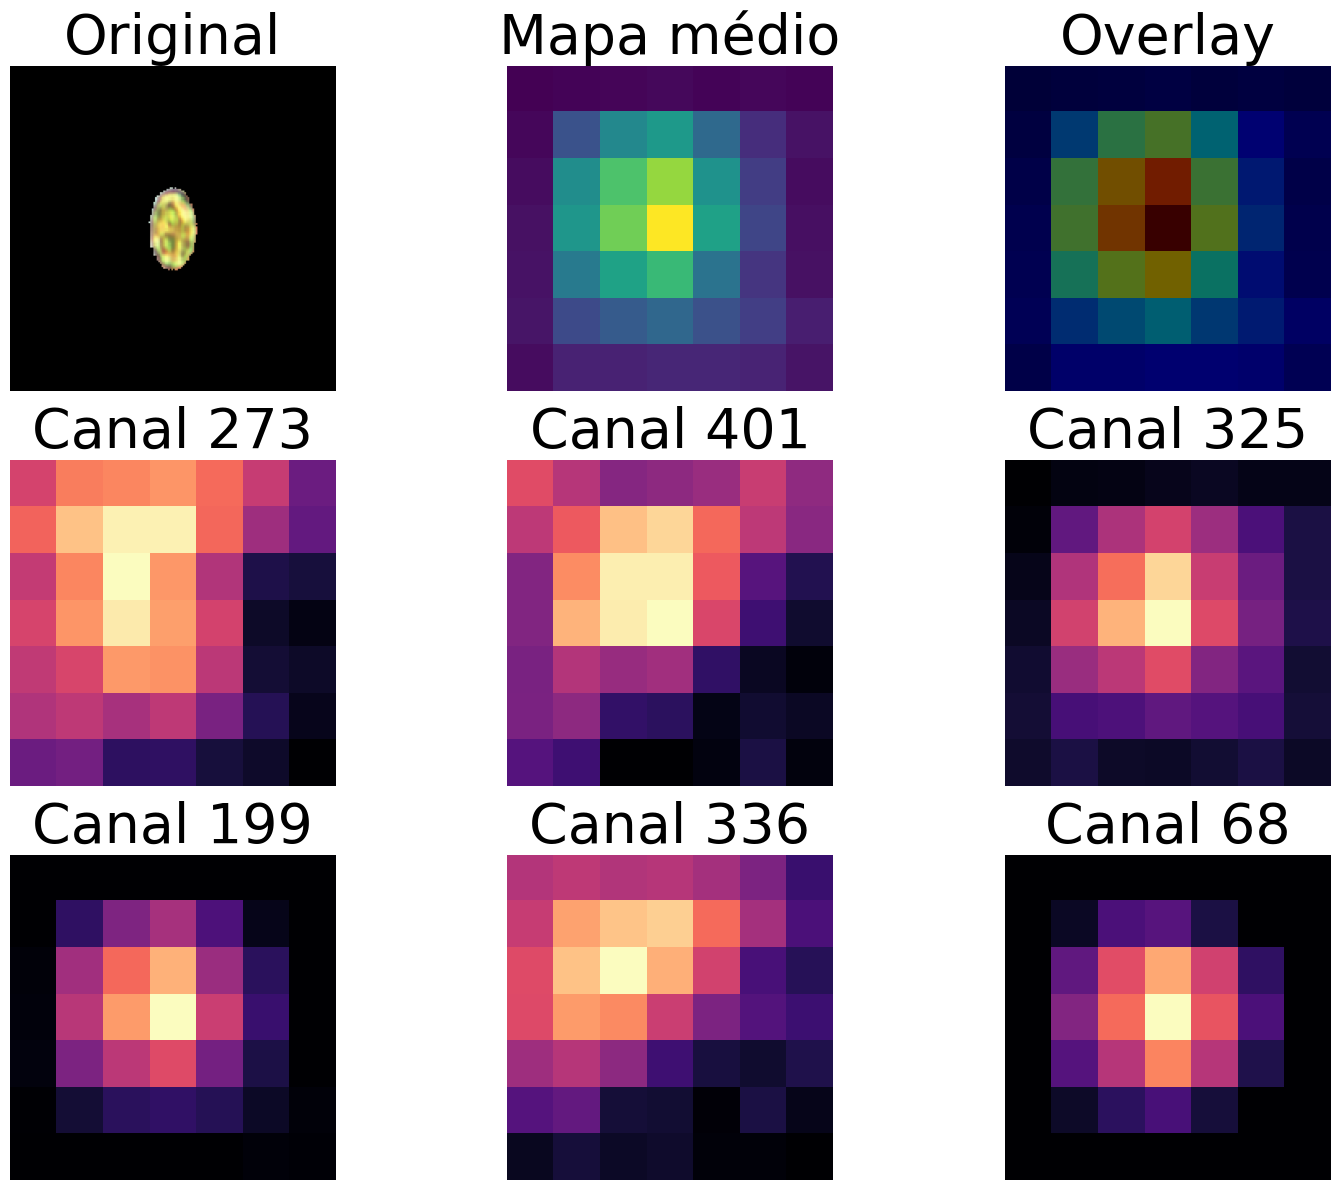

In [29]:
# Visualizar mapa de ativação após a última camada convolucional (antes da FC)

def _find_first_dataloader(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            dl = _find_first_dataloader(v)
            if dl is not None:
                return dl
    elif hasattr(obj, "dataset") and hasattr(obj, "__iter__"):
        return obj
    return None

loader = _find_first_dataloader(dataloaders)
if loader is None:
    raise ValueError("Nenhum DataLoader encontrado em 'dataloaders'.")

# quero escolher a classe da imagem
chosen_class = 1  # Altere para a classe desejada (0 a num_classes-1)

num_classes = config["num_classes"]
if not (0 <= chosen_class < num_classes):
    raise ValueError(f"chosen_class={chosen_class} inválida. Use valores entre 0 e {num_classes - 1}.")

# pegar a primeira imagem da classe escolhida (procurando em todos os batches)
images = None
for batch_images, batch_labels in loader:
    mask = (batch_labels == chosen_class)
    if mask.any().item():
        images = batch_images[mask][:1]  # 1 imagem
        break

if images is None:
    raise ValueError(f"Nenhuma imagem da classe {chosen_class} encontrada neste DataLoader.")

x = images.to(config["device"])  # 1 imagem

model_scratch = model_scratch.to(config["device"]).eval()

with torch.no_grad():
    h = model_scratch.conv1(x)
    h = model_scratch.bn1(h)
    h = model_scratch.relu(h)
    h = model_scratch.maxpool(h)

    h = model_scratch.layer1(h)
    h = model_scratch.layer2(h)
    h = model_scratch.layer3(h)
    feat = model_scratch.layer4(h)  # saída da última parte convolucional

    pooled = model_scratch.avgpool(feat)
    logits = model_scratch.fc(torch.flatten(pooled, 1))

print(f"Input shape: {x.shape}")
print(f"Feature map shape (última conv): {feat.shape}")
print(f"Logits shape: {logits.shape}")

# --- Preparar imagem original (desnormalizar para plot) ---
img_np = images[0].permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

feat_cpu = feat[0].detach().cpu()  # [C, H, W]

# Mapa agregado (média nos canais)
mean_map = feat_cpu.mean(dim=0).numpy()
mean_map = (mean_map - mean_map.min()) / (mean_map.max() - mean_map.min() + 1e-8)

# Top-6 canais mais "ativos"
channel_score = feat_cpu.view(feat_cpu.size(0), -1).mean(dim=1)
k = min(6, feat_cpu.size(0))
top_idx = torch.topk(channel_score, k=k).indices

# --- Plot em grade 3x3 (9 posições): original, média, overlay + 6 canais ---
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

# plt.suptitle(
#     f"Mapa de Ativação - ResNet18 | Classe {chosen_class}",
#     fontsize=18,
#     fontweight="bold"
# )

qtd  = 40

# 1) imagem original
axes[0].imshow(img_np)
axes[0].set_title("Original", fontsize=qtd)
axes[0].axis("off")

# 2) mapa médio
axes[1].imshow(mean_map, cmap="viridis")
# axes[1].set_title("Mapa médio (última conv)", fontsize=qtd)
axes[1].set_title("Mapa médio", fontsize=qtd)
axes[1].axis("off")

# 3) overlay
axes[2].imshow(img_np)
axes[2].imshow(mean_map, cmap="jet", alpha=0.45)
axes[2].set_title("Overlay", fontsize=qtd)
axes[2].axis("off")

# 4..12) top-9 canais
for i, ch in enumerate(top_idx, start=3):
    fmap = feat_cpu[ch].numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    axes[i].imshow(fmap, cmap="magma")
    axes[i].set_title(f"Canal {int(ch)}", fontsize=qtd)
    axes[i].axis("off")

# caso k < 9, desliga eixos restantes
for j in range(3 + k, 9):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


Input shape: torch.Size([1, 3, 200, 200])
Feature map shape (última conv): torch.Size([1, 512, 7, 7])
Logits shape: torch.Size([1, 7])


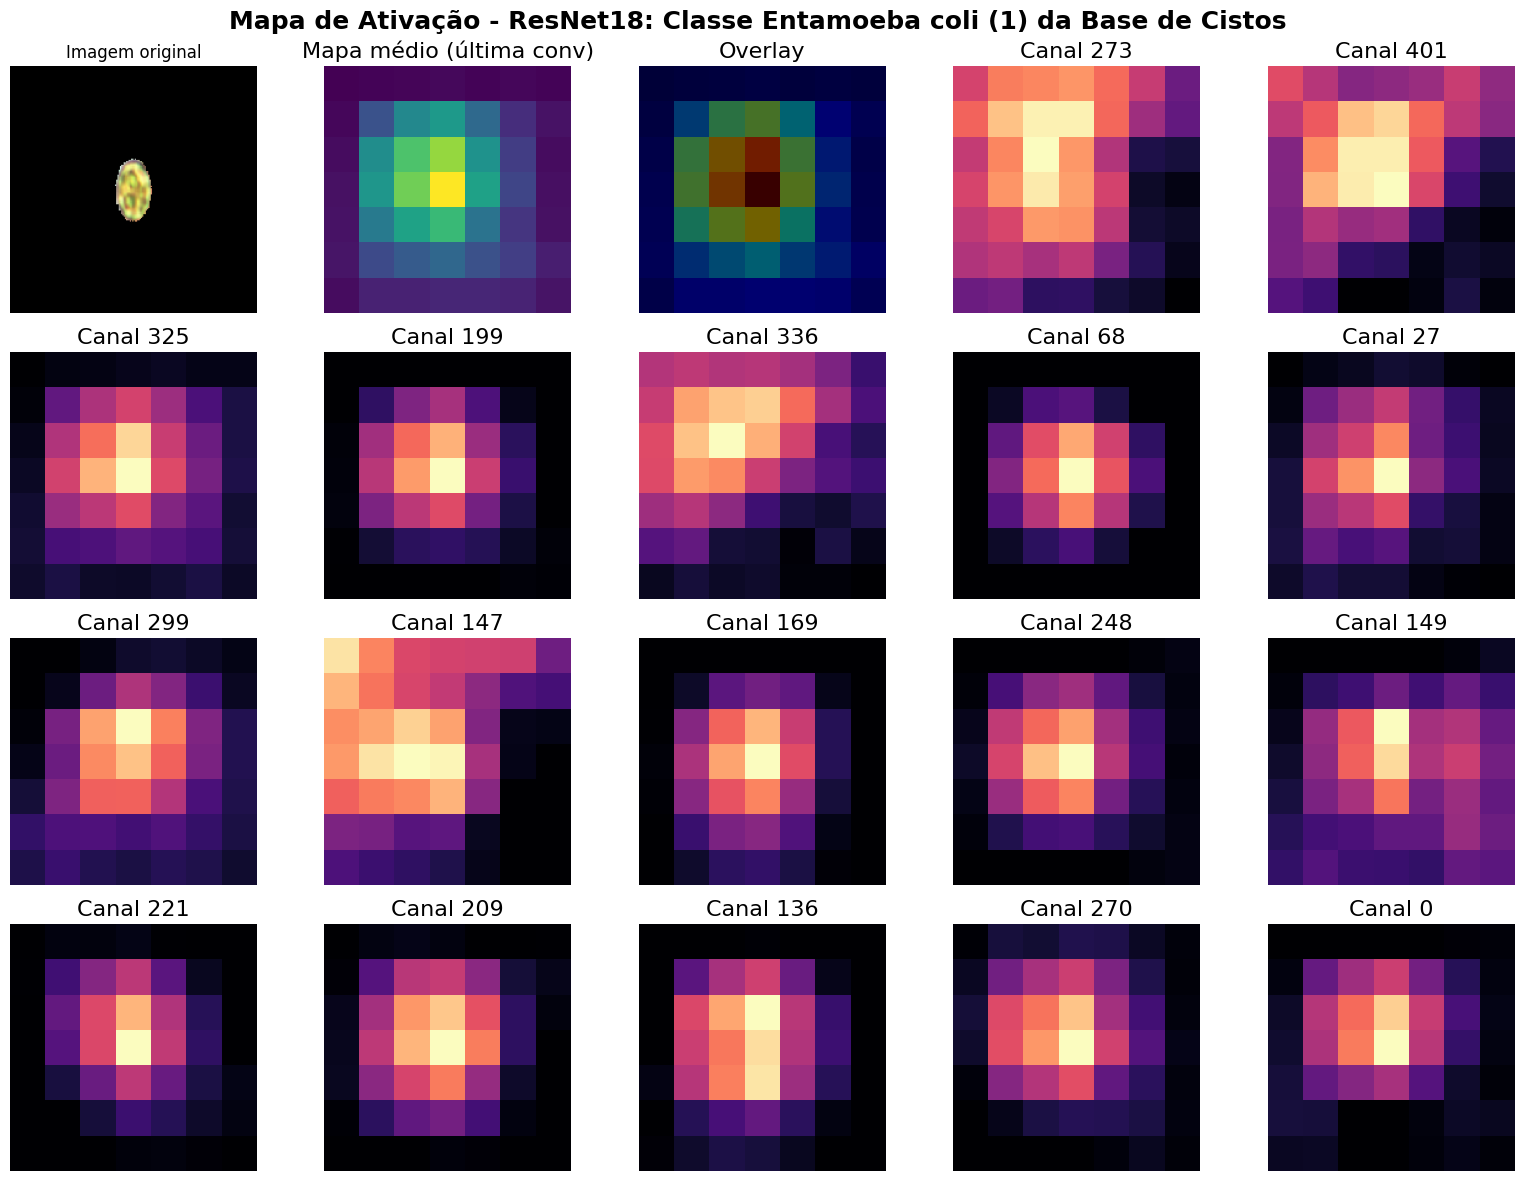

In [40]:
# Visualizar mapa de ativação após a última camada convolucional (antes da FC)

def _find_first_dataloader(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            dl = _find_first_dataloader(v)
            if dl is not None:
                return dl
    elif hasattr(obj, "dataset") and hasattr(obj, "__iter__"):
        return obj
    return None

loader = _find_first_dataloader(dataloaders)
if loader is None:
    raise ValueError("Nenhum DataLoader encontrado em 'dataloaders'.")

# quero escolher a classe da imagem
chosen_class = 1  # Altere para a classe desejada (0 a num_classes-1)

num_classes = config["num_classes"]
if not (0 <= chosen_class < num_classes):
    raise ValueError(f"chosen_class={chosen_class} inválida. Use valores entre 0 e {num_classes - 1}.")

# pegar a primeira imagem da classe escolhida (procurando em todos os batches)
images = None
for batch_images, batch_labels in loader:
    mask = (batch_labels == chosen_class)
    if mask.any().item():
        images = batch_images[mask][:1]  # 1 imagem
        break

if images is None:
    raise ValueError(f"Nenhuma imagem da classe {chosen_class} encontrada neste DataLoader.")

x = images.to(config["device"])  # 1 imagem

model_scratch = model_scratch.to(config["device"]).eval()

with torch.no_grad():
    h = model_scratch.conv1(x)
    h = model_scratch.bn1(h)
    h = model_scratch.relu(h)
    h = model_scratch.maxpool(h)

    h = model_scratch.layer1(h)
    h = model_scratch.layer2(h)
    h = model_scratch.layer3(h)
    feat = model_scratch.layer4(h)  # saída da última parte convolucional

    pooled = model_scratch.avgpool(feat)
    logits = model_scratch.fc(torch.flatten(pooled, 1))

print(f"Input shape: {x.shape}")
print(f"Feature map shape (última conv): {feat.shape}")
print(f"Logits shape: {logits.shape}")

# --- Preparar imagem original (desnormalizar para plot) ---
img_np = images[0].permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

feat_cpu = feat[0].detach().cpu()  # [C, H, W]

# Mapa agregado (média nos canais)
mean_map = feat_cpu.mean(dim=0).numpy()
mean_map = (mean_map - mean_map.min()) / (mean_map.max() - mean_map.min() + 1e-8)

# Top-17 canais mais "ativos"
channel_score = feat_cpu.view(feat_cpu.size(0), -1).mean(dim=1)
k = min(17, feat_cpu.size(0))
top_idx = torch.topk(channel_score, k=k).indices

# --- Plot ---
fig = plt.figure(figsize=(16, 12))
plt.suptitle(f"Mapa de Ativação - ResNet18: Classe Entamoeba coli ({chosen_class}) da Base de Cistos ", fontsize=18, fontweight='bold')

ax1 = plt.subplot(4, 5, 1)
ax1.imshow(img_np)
ax1.set_title("Imagem original")
ax1.axis("off")

ax2 = plt.subplot(4, 5, 2)
ax2.imshow(mean_map, cmap="viridis")
ax2.set_title("Mapa médio (última conv)", fontsize=16)
ax2.axis("off")

ax3 = plt.subplot(4, 5, 3)
ax3.imshow(img_np)
ax3.imshow(mean_map, cmap="jet", alpha=0.45)
ax3.set_title("Overlay", fontsize=16)
ax3.axis("off")

for i, ch in enumerate(top_idx, start=4):
    ax = plt.subplot(4, 5, i)
    fmap = feat_cpu[ch].numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    ax.imshow(fmap, cmap="magma")
    ax.set_title(f"Canal {int(ch)}", fontsize=16)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [27]:
# Training loop with pre-trained weights
historic_train = trainer.train_loop(config, dataloaders, path, dataset_name, model_name=model_name, type_model=type_model, pre_trained=pre_trained)

# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)
    

Early stopping at epoch 48 for split 1 and percentage 1%


Early stopping at epoch 21 for split 2 and percentage 1%


Early stopping at epoch 27 for split 3 and percentage 1%


Early stopping at epoch 89 for split 1 and percentage 5%


Early stopping at epoch 63 for split 2 and percentage 5%


...

Early stopping at epoch 42 for split 2 and percentage 75%


Early stopping at epoch 64 for split 3 and percentage 75%


Early stopping at epoch 48 for split 1 and percentage 100%


Early stopping at epoch 42 for split 2 and percentage 100%


Early stopping at epoch 32 for split 3 and percentage 100%


In [28]:
utils.loss_and_accuracy_split(config, path, model_name, show_plot=False)
utils.loss_and_accuracy_aggregate(config, path, model_name, show_plot=False)

results_test = utils.evaluate_test_set(config, path, model_name, dataloaders, type_model=type_model, pre_trained=pre_trained)  

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)

utils.calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to resnet18/resnet18_pretrained/cistos/resnet18_pretrained_aggregated_classification_report_cistos.txt
